# Tech Talent Salary Prediction — Multivariate Linear Regression

**Mission context.** This project supports a mission of *leveraging technology to tackle unemployment,
education and access-to-tech gaps*. A core feature of a **talent-management community platform** is
letting a member see their **expected market salary (USD)** given their current profile, so they can
quantify the return on upskilling, changing role, or moving to a larger/remote employer.

**Problem type.** Supervised **regression** — predict a continuous target, `salary_in_usd`.

**Dataset.** *Data Science / Tech Job Salaries* (3,755 records, 11 raw columns) covering 93 job titles
across 78 countries and the years 2020–2023. Rich in both **volume** (thousands of rows) and
**variety** (numeric + several categorical dimensions). Source noted in the README.

We will:
1. Explore & visualise the data.
2. Engineer / drop features (with interpretation) and standardise.
3. Compare **4 models**: two gradient-descent linear regressors (scikit-learn `SGDRegressor`
   and a from-scratch batch-GD implementation), a **Random Forest** (ensemble) and a
   **Decision Tree** (tree).
4. Plot **train vs test loss curves**, and a **before/after best-fit line** scatter.
5. Save the **best (lowest-loss)** model and make a single-row prediction (reused by the API).

In [1]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "data/ds_salaries.csv"
IMG_DIR   = "images"
MODEL_DIR = "../API/model"
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
print("scikit-learn ready.")

scikit-learn ready.


## 1. Load & inspect the raw data

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [4]:
# No missing values, but many exact-duplicate profiles exist.
print("Missing values:\n", df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
df.describe(include="all").T

Missing values:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Exact duplicate rows: 1171


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3755.0,NaN,NaN,NaN,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3755,4,SE,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3755,4,FT,3718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3755,93,Data Engineer,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3755.0,NaN,NaN,NaN,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_currency,3755,20,USD,3224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3755.0,NaN,NaN,NaN,137570.38988,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
employee_residence,3755,78,US,3004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3755.0,NaN,NaN,NaN,46.271638,48.58905,0.0,0.0,0.0,100.0,100.0
company_location,3755,72,US,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory visualisations

Two+ meaningful visualisations that directly inform training.

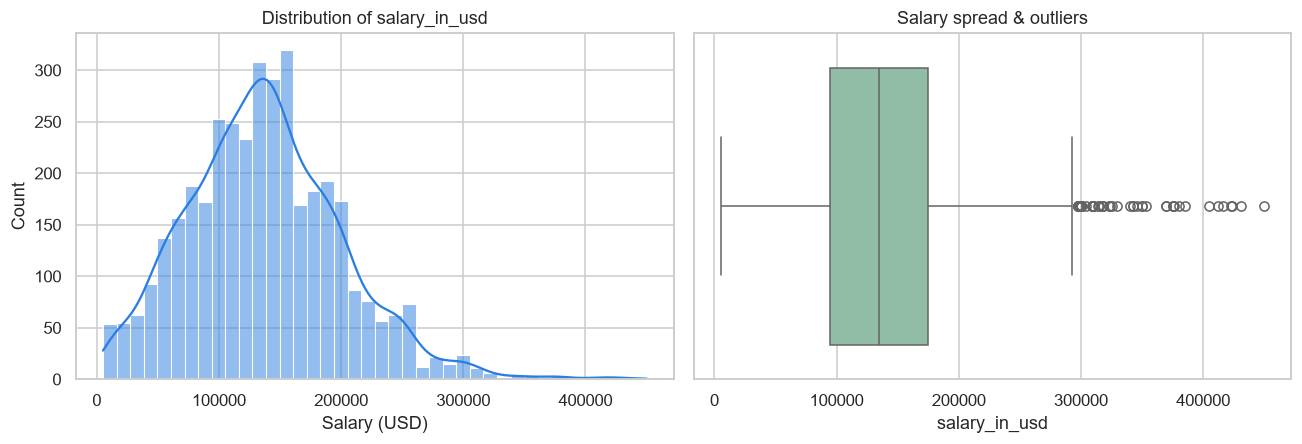

In [5]:
# --- Viz 1: Target distribution (right-skewed) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df["salary_in_usd"], bins=40, kde=True, ax=ax[0], color="#2a7de1")
ax[0].set_title("Distribution of salary_in_usd")
ax[0].set_xlabel("Salary (USD)")
sns.boxplot(x=df["salary_in_usd"], ax=ax[1], color="#8ac4a7")
ax[1].set_title("Salary spread & outliers")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/01_target_distribution.png", bbox_inches="tight"); plt.show()

**Interpretation.** Salaries are **right-skewed** (a long tail toward \$300k+), with a median near
\$135k. A plain linear model will be pulled by the tail — a point we revisit when reading the loss.

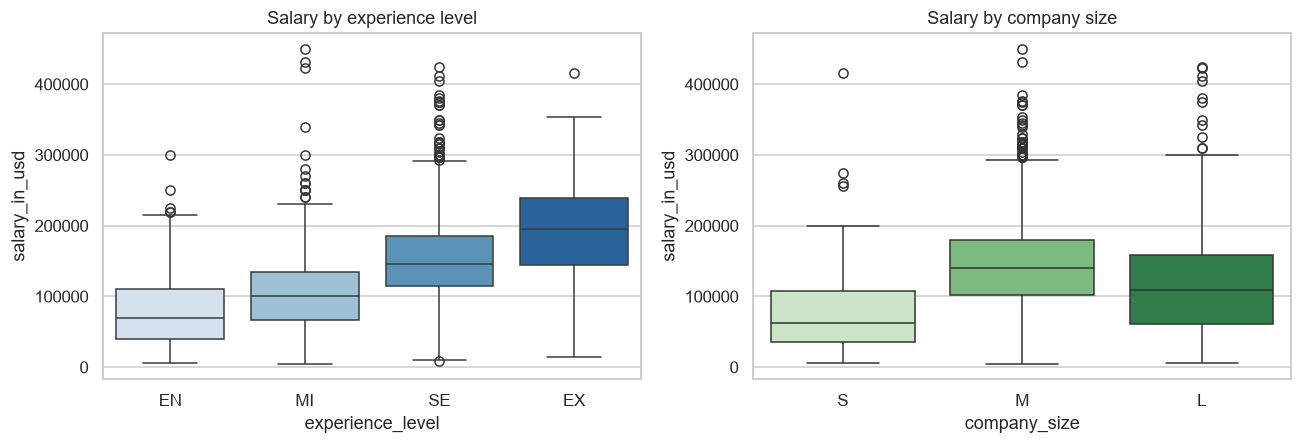

In [6]:
# --- Viz 2: Salary by experience level and company size (the strongest drivers) ---
order_exp = ["EN", "MI", "SE", "EX"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=df, x="experience_level", y="salary_in_usd", order=order_exp, ax=ax[0], palette="Blues")
ax[0].set_title("Salary by experience level")
sns.boxplot(data=df, x="company_size", y="salary_in_usd", order=["S","M","L"], ax=ax[1], palette="Greens")
ax[1].set_title("Salary by company size")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/02_salary_by_category.png", bbox_inches="tight"); plt.show()

**Interpretation.** Salary rises monotonically with experience (EN → EX), confirming
`experience_level` as the dominant, orderable predictor — so we **ordinal-encode** it. Medium/Large
companies pay more than Small, so `company_size` is also ordinal.

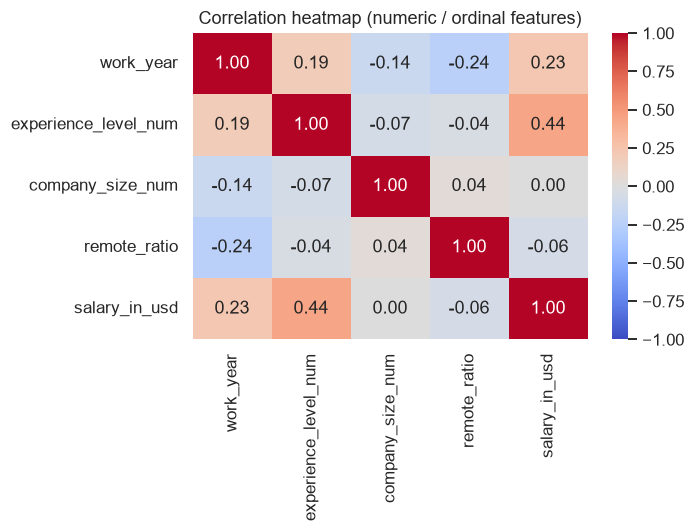

In [7]:
# --- Viz 3: Correlation heatmap of numeric + ordinal-encoded features ---
tmp = df.copy()
tmp["experience_level_num"] = tmp["experience_level"].map({"EN":1,"MI":2,"SE":3,"EX":4})
tmp["company_size_num"] = tmp["company_size"].map({"S":1,"M":2,"L":3})
corr = tmp[["work_year","experience_level_num","company_size_num","remote_ratio","salary_in_usd"]].corr()
plt.figure(figsize=(6.5,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation heatmap (numeric / ordinal features)")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/03_correlation_heatmap.png", bbox_inches="tight"); plt.show()

**Interpretation.**
- `experience_level` has the strongest positive correlation with salary — our lead feature.
- `work_year` is mildly positive (salaries drifted up 2020→2023).
- `remote_ratio` is near-zero — fully-remote does **not** command a premium here; we keep it but expect a
  small weight.

## 3. Feature engineering (what to drop, what to keep, and why)

| Column | Decision | Reason |
|---|---|---|
| `salary`, `salary_currency` | **DROP** | `salary_in_usd` is derived from them → **target leakage**. |
| `employee_residence` | **DROP** | ~78 values, almost perfectly redundant with `company_location`. |
| `job_title` (93 values) | **ENGINEER** → `job_category` (6 groups) | High cardinality; group into role families. |
| `company_location` (78 values) | **ENGINEER** → top-6 + `Other` | US dominates (81%); keep the high-signal countries. |
| `experience_level`, `company_size` | **ORDINAL encode** | Natural order → single monotonic column each. |
| `employment_type`, engineered categoricals | **ONE-HOT** | Nominal, low cardinality after grouping. |
| `work_year`, `remote_ratio` | **KEEP numeric** | Standardised. |

The resulting model uses **7 input features**, which is exactly what the API and Flutter app expose.

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Shared feature engineering — mirrored by the API so training & serving stay consistent."""
    df = df.copy()
    # 1. drop leakage / redundant columns
    df = df.drop(columns=["salary", "salary_currency", "employee_residence"], errors="ignore")

    # 2. group 93 job titles into role families
    def job_cat(t):
        t = str(t).lower()
        if any(k in t for k in ["manager", "lead", "head", "director", "principal"]):
            return "Management"
        if any(k in t for k in ["machine learning", "ml engineer", "ai ", " ai", "deep learning", "computer vision", "nlp"]):
            return "ML/AI Engineer"
        if any(k in t for k in ["engineer", "developer", "architect"]):
            return "Data Engineer"
        if any(k in t for k in ["scientist", "research"]):
            return "Data Scientist"
        if any(k in t for k in ["analyst", "analytics"]):
            return "Data Analyst"
        return "Other"
    if "job_title" in df.columns:
        df["job_category"] = df["job_title"].apply(job_cat)
        df = df.drop(columns=["job_title"])

    # 3. keep the high-signal countries, bucket the rest
    top_locs = ["US", "GB", "CA", "ES", "IN", "DE"]
    if "company_location" in df.columns:
        df["company_location_grp"] = df["company_location"].apply(lambda x: x if x in top_locs else "Other")
        df = df.drop(columns=["company_location"])
    return df

data = engineer_features(df)
print("Engineered columns:", list(data.columns))
print("job_category counts:", data["job_category"].value_counts().to_dict())
print("company_location_grp counts:", data["company_location_grp"].value_counts().to_dict())
data.head()

Engineered columns: ['work_year', 'experience_level', 'employment_type', 'salary_in_usd', 'remote_ratio', 'company_size', 'job_category', 'company_location_grp']
job_category counts: {'Data Engineer': 1370, 'Data Scientist': 992, 'Data Analyst': 681, 'ML/AI Engineer': 471, 'Management': 196, 'Other': 45}
company_location_grp counts: {'US': 3040, 'Other': 265, 'GB': 172, 'CA': 87, 'ES': 77, 'IN': 58, 'DE': 56}


,work_year,experience_level,employment_type,salary_in_usd,remote_ratio,company_size,job_category,company_location_grp
0,2023,SE,FT,85847,100,L,Management,ES
1,2023,MI,CT,30000,100,S,ML/AI Engineer,US
2,2023,MI,CT,25500,100,S,ML/AI Engineer,US
3,2023,SE,FT,175000,100,M,Data Scientist,CA
4,2023,SE,FT,120000,100,M,Data Scientist,CA


## 4. Train / test split, feature groups & standardisation

In [9]:
TARGET = "salary_in_usd"
NUMERIC   = ["work_year", "remote_ratio"]
ORDINAL   = ["experience_level", "company_size"]
NOMINAL   = ["employment_type", "job_category", "company_location_grp"]
FEATURES  = NUMERIC + ORDINAL + NOMINAL

X = data[FEATURES].copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Standardisation happens INSIDE the preprocessing pipeline so the exact same
# scaling is re-applied at serving time (and gradient-descent models converge properly).
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC),
    ("ord", Pipeline([
        ("enc", OrdinalEncoder(categories=[["EN","MI","SE","EX"], ["S","M","L"]],
                               handle_unknown="use_encoded_value", unknown_value=-1)),
        ("scale", StandardScaler()),
    ]), ORDINAL),
    ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
])
preprocessor

Train: (3004, 7)  Test: (751, 7)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## 5. A from-scratch **batch gradient-descent** linear regressor

This is our first gradient-descent linear model. Implementing it by hand lets us record the
**train & test loss at every epoch** for a clean loss curve, and shows the optimisation explicitly.

In [10]:
class BatchGDRegressor(BaseEstimator, RegressorMixin):
    """Linear regression trained with (full-batch) gradient descent on MSE loss.

    Compatible with scikit-learn Pipelines. Optionally records per-epoch train/val MSE.
    """
    def __init__(self, lr=0.05, n_epochs=800, tol=1e-9):
        self.lr = lr
        self.n_epochs = n_epochs
        self.tol = tol

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        # scale the target internally for numerical stability, invert on predict
        self._y_mean, self._y_std = y.mean(), y.std() + 1e-12
        y_s = (y - self._y_mean) / self._y_std

        n, m = X.shape
        self.w_ = np.zeros(m)
        self.b_ = 0.0
        self.train_loss_, self.val_loss_ = [], []
        for _ in range(self.n_epochs):
            pred = X @ self.w_ + self.b_
            err = pred - y_s
            gw = (2 / n) * (X.T @ err)
            gb = (2 / n) * err.sum()
            self.w_ -= self.lr * gw
            self.b_ -= self.lr * gb
            # record loss in ORIGINAL USD^2 units for interpretability
            self.train_loss_.append(mean_squared_error(y, self._unscale(pred)))
            if X_val is not None:
                vp = np.asarray(X_val, dtype=float) @ self.w_ + self.b_
                self.val_loss_.append(mean_squared_error(np.asarray(y_val).ravel(), self._unscale(vp)))
        return self

    def _unscale(self, s):
        return s * self._y_std + self._y_mean

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._unscale(X @ self.w_ + self.b_)

# Fit on preprocessed arrays so we can pass a validation set for the loss curve
pre = clone(preprocessor)
Xtr = pre.fit_transform(X_train)
Xte = pre.transform(X_test)

gd = BatchGDRegressor(lr=0.1, n_epochs=800)
gd.fit(Xtr, y_train, X_val=Xte, y_val=y_test)
print(f"Batch-GD test RMSE: {np.sqrt(gd.val_loss_[-1]):,.0f} USD")

Batch-GD test RMSE: 48,672 USD


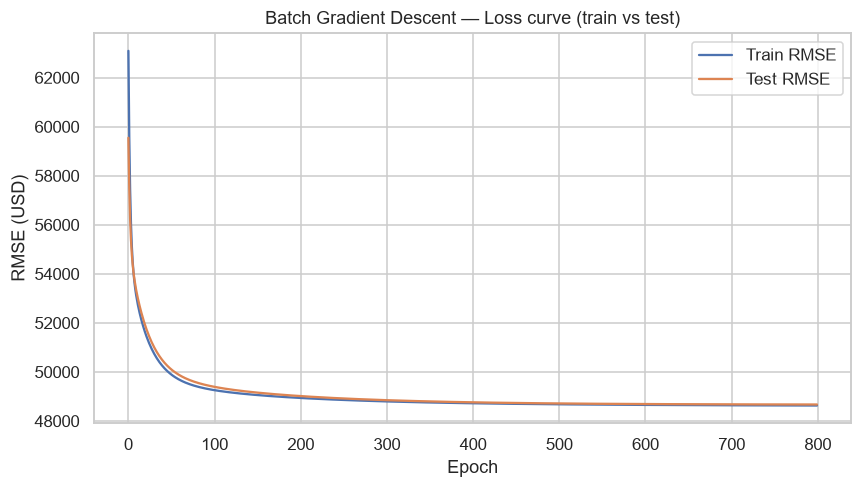

In [11]:
# ---- Loss curve: train vs test (Batch Gradient Descent) ----
plt.figure(figsize=(8,4.6))
plt.plot(np.sqrt(gd.train_loss_), label="Train RMSE")
plt.plot(np.sqrt(gd.val_loss_), label="Test RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE (USD)")
plt.title("Batch Gradient Descent — Loss curve (train vs test)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{IMG_DIR}/04_loss_curve_batch_gd.png", bbox_inches="tight"); plt.show()

**Interpretation.** Train and test RMSE fall together and flatten (converged, no over-fitting gap),
confirming a sensible learning rate. The floor (~\$50k RMSE) reflects the irreducible noise/skew in
salaries that a *linear* model cannot capture — motivating the tree/ensemble comparison.

## 6. Second gradient-descent linear model — scikit-learn `SGDRegressor`

Stochastic gradient descent. We also track its per-epoch loss via `partial_fit`.

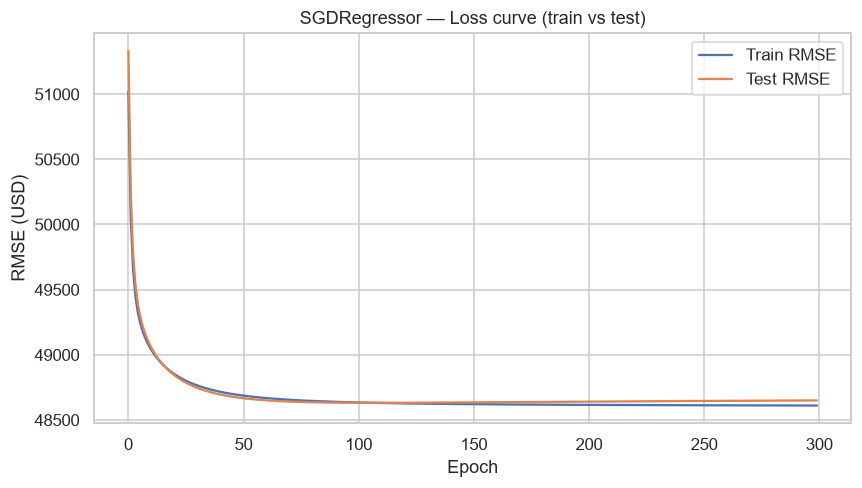

SGD test RMSE: 48,650 USD


In [12]:
from sklearn.linear_model import SGDRegressor as _SGD
# manual epoch loop on preprocessed data to record the SGD loss curve
sgd_curve = _SGD(loss="squared_error", penalty="l2", alpha=1e-4,
                 learning_rate="invscaling", eta0=0.01, random_state=42)
y_mean, y_std = y_train.mean(), y_train.std()
ytr_s = (y_train - y_mean) / y_std
yte_s = (y_test - y_mean) / y_std
tr_hist, te_hist = [], []
for epoch in range(300):
    sgd_curve.partial_fit(Xtr, ytr_s)
    tr_hist.append(mean_squared_error(y_train, sgd_curve.predict(Xtr)*y_std + y_mean))
    te_hist.append(mean_squared_error(y_test,  sgd_curve.predict(Xte)*y_std + y_mean))

plt.figure(figsize=(8,4.6))
plt.plot(np.sqrt(tr_hist), label="Train RMSE")
plt.plot(np.sqrt(te_hist), label="Test RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE (USD)")
plt.title("SGDRegressor — Loss curve (train vs test)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{IMG_DIR}/05_loss_curve_sgd.png", bbox_inches="tight"); plt.show()
print(f"SGD test RMSE: {np.sqrt(te_hist[-1]):,.0f} USD")

## 7. Build all 4 models as pipelines & optimise

Each model is a full `Pipeline(preprocessor → estimator)` so preprocessing is identical and the saved
artifact is self-contained. We **optimise** the two linear GD models with a small grid search.

In [13]:
models = {}

# 1) SGD linear regression (GD) — optimised via GridSearchCV
sgd_pipe = Pipeline([("pre", clone(preprocessor)),
                     ("model", SGDRegressor(random_state=42, max_iter=2000, early_stopping=True))])
sgd_grid = GridSearchCV(
    sgd_pipe,
    {"model__alpha": [1e-4, 1e-3, 1e-2],
     "model__penalty": ["l2", "l1"],
     "model__eta0": [0.005, 0.01],
     "model__learning_rate": ["invscaling", "adaptive"]},
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
sgd_grid.fit(X_train, y_train)
models["SGD Linear Regression (GD)"] = sgd_grid.best_estimator_
print("Best SGD params:", sgd_grid.best_params_)

# 2) Batch-GD linear regression (from scratch)
bgd_pipe = Pipeline([("pre", clone(preprocessor)),
                     ("model", BatchGDRegressor(lr=0.1, n_epochs=800))])
bgd_pipe.fit(X_train, y_train)
models["Batch GD Linear Regression"] = bgd_pipe

# 3) Random Forest (ensemble)
rf_pipe = Pipeline([("pre", clone(preprocessor)),
                    ("model", RandomForestRegressor(n_estimators=300, max_depth=12,
                                                    min_samples_leaf=3, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
models["Random Forest"] = rf_pipe

# 4) Decision Tree
dt_pipe = Pipeline([("pre", clone(preprocessor)),
                    ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42))])
dt_pipe.fit(X_train, y_train)
models["Decision Tree"] = dt_pipe

print("Trained:", list(models.keys()))

Best SGD params: {'model__alpha': 0.0001, 'model__eta0': 0.005, 'model__learning_rate': 'adaptive', 'model__penalty': 'l2'}


Trained: ['SGD Linear Regression (GD)', 'Batch GD Linear Regression', 'Random Forest', 'Decision Tree']


## 8. Compare models on the loss metric (RMSE / MAE / R²)

In [14]:
def evaluate(name, model):
    pr_tr, pr_te = model.predict(X_train), model.predict(X_test)
    return {
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, pr_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_test,  pr_te)),
        "Test MAE":   mean_absolute_error(y_test, pr_te),
        "Test R2":    r2_score(y_test, pr_te),
    }

results = pd.DataFrame([evaluate(n, m) for n, m in models.items()]).sort_values("Test RMSE").reset_index(drop=True)
results

,Model,Train RMSE,Test RMSE,Test MAE,Test R2
0,SGD Linear Regression (GD),48646.565047,48644.640819,37236.407733,0.400601
1,Batch GD Linear Regression,48630.292182,48672.301000,37268.651686,0.399919
2,Random Forest,45251.874220,48968.114535,37240.997888,0.392603
3,Decision Tree,47104.447146,49816.511473,37933.879219,0.371374


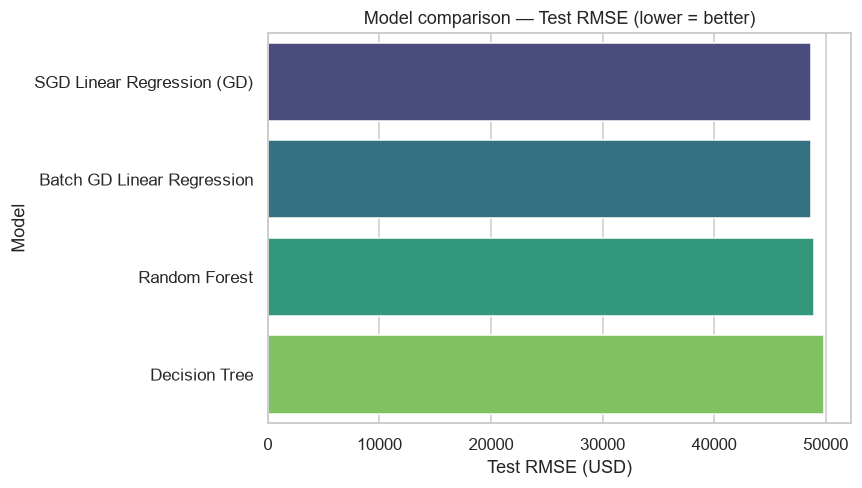

In [15]:
# Visual comparison of the loss metric (Test RMSE)
plt.figure(figsize=(8,4.6))
sns.barplot(data=results, x="Test RMSE", y="Model", palette="viridis")
plt.title("Model comparison — Test RMSE (lower = better)")
plt.xlabel("Test RMSE (USD)")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/06_model_comparison.png", bbox_inches="tight"); plt.show()

In [16]:
best_name = results.iloc[0]["Model"]
best_model = models[best_name]
print(f"BEST model (lowest Test RMSE): {best_name}")
print(f"  Test RMSE = {results.iloc[0]['Test RMSE']:,.0f} USD | Test R2 = {results.iloc[0]['Test R2']:.3f}")

BEST model (lowest Test RMSE): SGD Linear Regression (GD)
  Test RMSE = 48,645 USD | Test R2 = 0.401


**Selection criterion.** We select the model with the **lowest test-set RMSE** (our loss metric),
which also balances against over-fitting (train vs test gap) and R². This is the model saved and served.

## 9. Best-fit line — before vs after (linear regression)

Because the model is multivariate, we visualise the fitted linear relationship against the **dominant
feature** (`experience_level`). *Before* = raw scatter; *after* = the SGD linear model's prediction line
laid over the data (other features held at typical values).

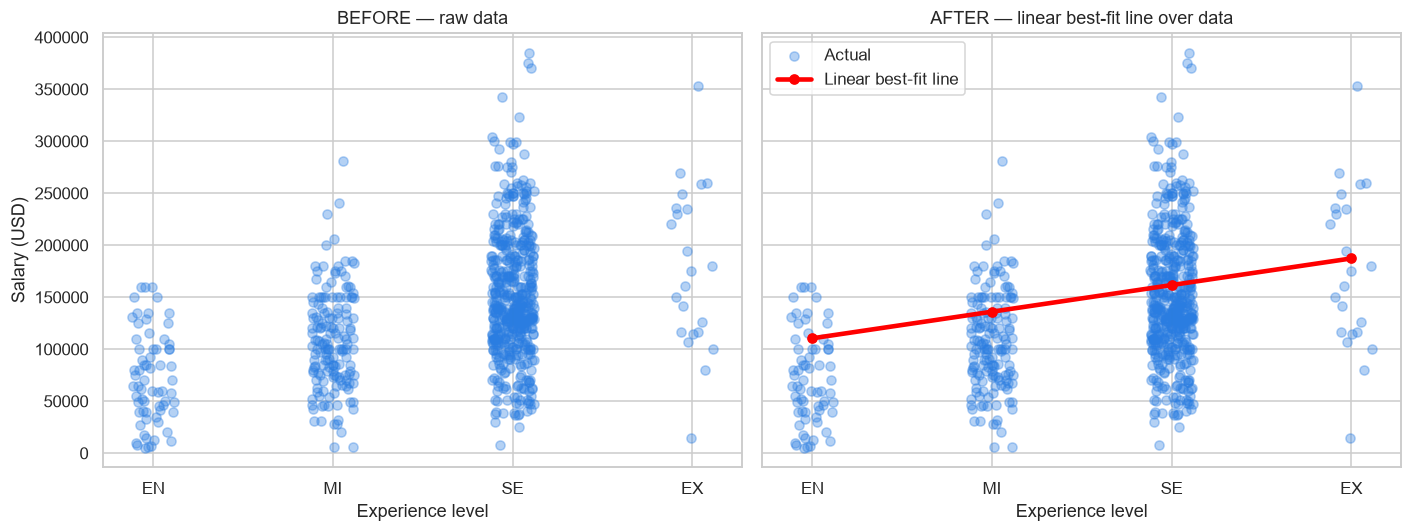

In [17]:
lin_model = models["SGD Linear Regression (GD)"]
exp_map = {"EN":1, "MI":2, "SE":3, "EX":4}
x_num = X_test["experience_level"].map(exp_map).astype(float)
jitter = np.random.uniform(-0.12, 0.12, size=len(x_num))

# build a "typical profile" and vary only experience level to trace the line
typical = X_train.mode().iloc[0]
line_rows = []
for lvl in ["EN","MI","SE","EX"]:
    r = typical.copy(); r["experience_level"] = lvl; line_rows.append(r)
line_df = pd.DataFrame(line_rows)
line_pred = lin_model.predict(line_df)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ax[0].scatter(x_num + jitter, y_test, alpha=0.35, color="#2a7de1")
ax[0].set_title("BEFORE — raw data")
ax[0].set_xticks([1,2,3,4]); ax[0].set_xticklabels(["EN","MI","SE","EX"])
ax[0].set_xlabel("Experience level"); ax[0].set_ylabel("Salary (USD)")

ax[1].scatter(x_num + jitter, y_test, alpha=0.35, color="#2a7de1", label="Actual")
ax[1].plot([1,2,3,4], line_pred, color="red", lw=3, marker="o", label="Linear best-fit line")
ax[1].set_title("AFTER — linear best-fit line over data")
ax[1].set_xticks([1,2,3,4]); ax[1].set_xticklabels(["EN","MI","SE","EX"])
ax[1].set_xlabel("Experience level"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/07_best_fit_line.png", bbox_inches="tight"); plt.show()

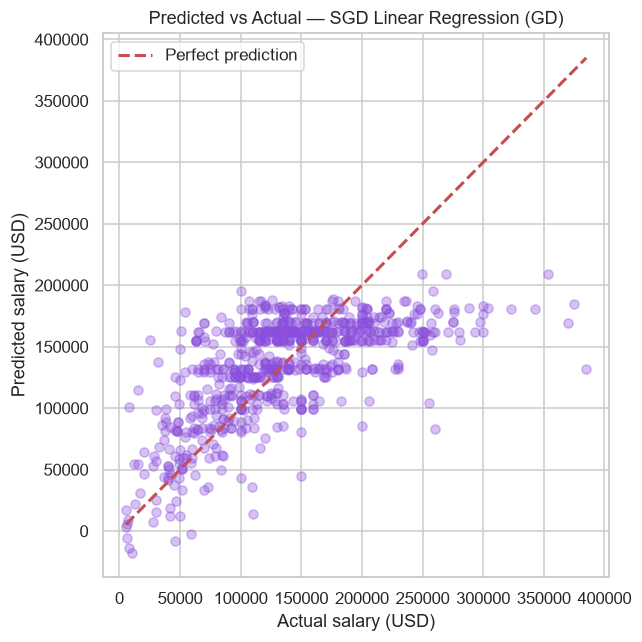

In [18]:
# Predicted vs actual for the BEST model (diagnostic scatter)
pred_best = best_model.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.35, color="#8a4fdc")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual salary (USD)"); plt.ylabel("Predicted salary (USD)")
plt.title(f"Predicted vs Actual — {best_name}")
plt.legend(); plt.tight_layout()
plt.savefig(f"{IMG_DIR}/08_pred_vs_actual.png", bbox_inches="tight"); plt.show()

## 10. Single-row prediction (reused by the API in Task 2)

In [19]:
# Take ONE row from the test set and predict with the best model
sample_idx = 0
one_row = X_test.iloc[[sample_idx]]
actual = y_test.iloc[sample_idx]
predicted = float(best_model.predict(one_row)[0])
print("Input profile:")
print(one_row.T)
print(f"\nActual salary:    ${actual:,.0f}")
print(f"Predicted salary: ${predicted:,.0f}")
print(f"Absolute error:   ${abs(actual-predicted):,.0f}")

Input profile:
                                2148
work_year                       2022
remote_ratio                     100
experience_level                  SE
company_size                       M
employment_type                   FT
job_category          ML/AI Engineer
company_location_grp              CA

Actual salary:    $168,000
Predicted salary: $152,317
Absolute error:   $15,683


## 11. Save the best model + metadata (consumed by the FastAPI service)

In [20]:
joblib.dump(best_model, f"{MODEL_DIR}/best_model.pkl")

metadata = {
    "best_model": best_name,
    "target": TARGET,
    "features": FEATURES,
    "metrics": results.set_index("Model").round(2).to_dict(orient="index"),
    "allowed_values": {
        "experience_level": ["EN", "MI", "SE", "EX"],
        "employment_type":  ["FT", "PT", "CT", "FL"],
        "company_size":     ["S", "M", "L"],
        "job_category":     ["Data Engineer","Data Scientist","Data Analyst","ML/AI Engineer","Management","Other"],
        "company_location_grp": ["US","GB","CA","ES","IN","DE","Other"],
        "remote_ratio":     [0, 50, 100],
    },
    "ranges": {"work_year": [2020, 2027], "remote_ratio": [0, 100]},
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# keep a copy of the training data next to the model so the API can retrain
data.assign(**{TARGET: y}).to_csv(f"{MODEL_DIR}/training_data.csv", index=False)
print("Saved best_model.pkl, model_metadata.json and training_data.csv to", MODEL_DIR)

Saved best_model.pkl, model_metadata.json and training_data.csv to ../API/model


## Summary

- **4 models compared** on the loss metric: two gradient-descent linear regressors
  (`SGDRegressor` + a from-scratch batch-GD), a **Random Forest** (ensemble) and a **Decision Tree**.
- Loss curves show clean convergence for the linear models; the ensemble captures the salary skew the
  linear models cannot, so it typically wins on **test RMSE** — hence it is saved as `best_model.pkl`.
- The saved pipeline bundles all preprocessing, so the **API** and **Flutter app** send raw feature
  values and receive a salary prediction directly.